# Lab 4: Polynomial Regression and Cross-Validation

## Background

Turbidity measures how much light is blocked by suspended particles in water. During a major storm like a hurricane, wind and rainfall stir up sediment and carry organic material into rivers, causing turbidity levels to spike. When light is blocked, aquatic photosynthesis slows, which reduces dissolved oxygen (DO). The relationship between turbidity and DO is not linear; it curves and flattens at extreme values.

In this lab we use 15-minute continuous sensor data from the Hudson River during **Hurricane Irene (August 25 – September 5, 2011)**, collected by HRECOS. We will:

- Fit a **simple linear regression** as a baseline and compute test MSE
- Check if a **polynomial regression** is a better fit than linear regression
- Use a **for loop with cross-validation** to find the polynomial degrees (from 1 to 10) that  yields the best MSE
- Select the best degree and evaluate it on the test set

## Setup: Load Libraries and Read in Data

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

url = "https://docs.google.com/spreadsheets/d/1MsSf679OsQpt4y6btV3tLPf-i8_bdoTZ/export?format=xlsx"

hurricane_do        = pd.read_excel(url, sheet_name=5)
hurricane_turbidity = pd.read_excel(url, sheet_name=2)

df = hurricane_do.merge(hurricane_turbidity, on='Date Time (ET)').drop(
    ['Piermont D.O. (ppm)', 'Piermont Turbidity in NTU', 'Norrie Point Turbidity in NTU','Norrie Point D.O. (ppm)'], axis=1
)
df.columns = ['date', 'albany_DO', 'albany_turbidity']

print(f'Shape: {df.shape}')
df.head()

Shape: (1152, 3)


,date,albany_DO,albany_turbidity
0,2011-08-25 00:00:00,7.68,4.0
1,2011-08-25 00:15:00,7.60,3.9
2,2011-08-25 00:30:00,7.57,4.3
3,2011-08-25 00:45:00,7.72,4.7
4,2011-08-25 01:00:00,7.74,4.4


## Step 1: Explore the Data

Plot dissolved oxygen against turbidity at Port of Albany to see whether the relationship looks linear or curved.

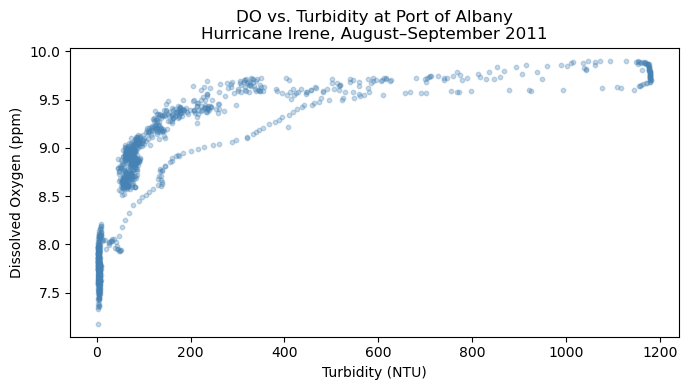

In [180]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['albany_turbidity'], df['albany_DO'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('DO vs. Turbidity at Port of Albany\nHurricane Irene, August–September 2011')
plt.tight_layout()
plt.show()

>**What do you notice?** Does the relationship look linear? Does a linear regression line seem like a good fit?

## Step 2: Prepare Features and Split Data

1. Build `X` from `albany_turbidity` (reshape to a 2D column vector with `.reshape(-1, 1)`) and `y` from `albany_DO`.
2. Split into 70% train / 30% test using `train_test_split` with `random_state=42`.

In [181]:
X = df['albany_turbidity'].values.reshape(-1, 1)
y = df['albany_DO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Training observations : {len(X_train)}')
print(f'Test observations     : {len(X_test)}')

Training observations : 806
Test observations     : 346


## Step 3: Fit a Baseline Linear Regression

Fit a **degree-1 polynomial** (linear regression) and record its test MSE. This is our baseline.

1. Initialize a `LinearRegression` model and fit it on `X_train` / `y_train`.
2. Predict on `X_test` and compute test MSE.
3. Plot the fitted line over the test scatter.

Linear regression test MSE: 0.2895


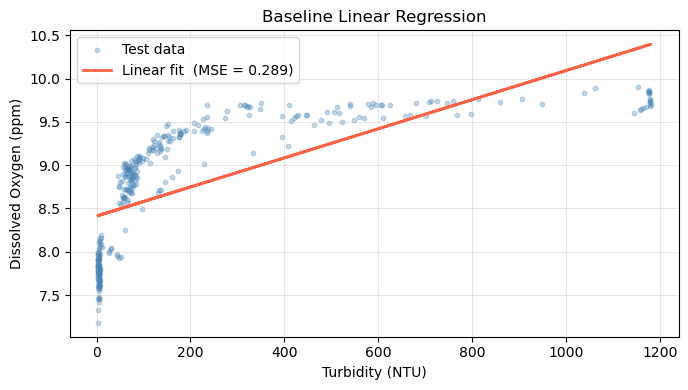

In [182]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_lr)
print(f'Linear regression test MSE: {mse_linear:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_test, y_test, alpha=0.3, s=10, color='steelblue', label='Test data')
ax.plot(X_test, y_pred_lr, color='tomato', linewidth=2,
        label=f'Linear fit  (MSE = {mse_linear:.3f})')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('Baseline Linear Regression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Polynomial Regression

Linear regression assumes a straight-line relationship between the response and predictor:

$$\hat{y} = \beta_0 + \beta_1 x$$

But in many real-world settings, that relationship is non-linear. Consider the plot above where the relationship between turbidity and dissolved oxygen follows a curve, not a line. A straight-line model will miss that relationship.

A simple way to handle this is **polynomial regression**: include transformed (higher-degree) versions of the predictor as additional features. For degree $d$:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

While this may appear non-linear, it is still a **linear model**.  It is linear in the *coefficients* $\beta_0, \beta_1, \ldots, \beta_d$. That means we can estimate all the coefficients using ordinary least squares, just as in multiple linear regression, where $X_1 = x$, $X_2 = x^2$, and so on.

 Higher degrees terms can often overfit, producing an unnecessarily wiggly curve that captures noise rather than signal. Cross Validation can help us find a degree that prevents overfitting. 

In `scikit-learn`, `PolynomialFeatures` handles the feature transformation. **Always fit it on the training set and use `transform()` on the test set** — fitting on all the data would leak test information into the model.

## Step 4: Fit a 2 degree polynomial

- Use `PolynomialFeatures(degree=2)` to transform `X_train` and `X_test`
- Fit a `LinearRegression` on the transformed training data
- Compute and print the test MSE

In [183]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
print(f'Linear regression test MSE  : {mse_linear:.4f}')
print(f'Degree-2 polynomial test MSE: {mse_poly:.4f}')

Linear regression test MSE  : 0.2895
Degree-2 polynomial test MSE: 0.1511


## Step 5: Compare Polynomial Degrees with Cross-Validation

Picking the best degree by checking test MSE is data leakage since we would be using the test set to choose the model. Instead, we use **k-fold cross-validation on the training set** to  estimate the error for every degree.

We will iterate over 10 different polynomial degress and perform cross validation with each one to find the lowest MSE. 

Note: `cross_val_score` with `scoring='neg_mean_squared_error'` returns **negative** MSE, so we negate the scores to get positive MSE values.

In [187]:
degrees      = list(range(1, 12))
cv_mean_mses = []

for degree in degrees:
    poly         = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)

    lr     = LinearRegression()
    scores = cross_val_score(lr, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_mean_mses.append(-scores.mean())

cv_mean_mses = np.array(cv_mean_mses)

optimal_degree = degrees[np.argmin(cv_mean_mses)]
best_cv_mse    = cv_mean_mses.min()

for degree, mse in zip(degrees, cv_mean_mses):
    print(f"Degree {degree}: MSE = {mse:.4f}")

Degree 1: MSE = 0.2841
Degree 2: MSE = 0.1378
Degree 3: MSE = 0.0735
Degree 4: MSE = 0.0424
Degree 5: MSE = 0.0340
Degree 6: MSE = 0.1166
Degree 7: MSE = 0.2197
Degree 8: MSE = 0.2831
Degree 9: MSE = 0.3257
Degree 10: MSE = 0.3986
Degree 11: MSE = 0.4105


## Step 6: Visualize CV MSE Across Polynomial Degrees

Plot mean CV MSE for each degree and mark the best one.

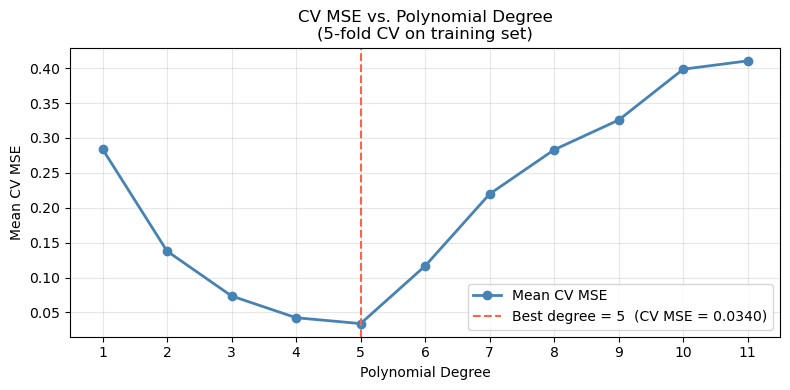

Best polynomial degree : 5
Best mean CV MSE       : 0.0340


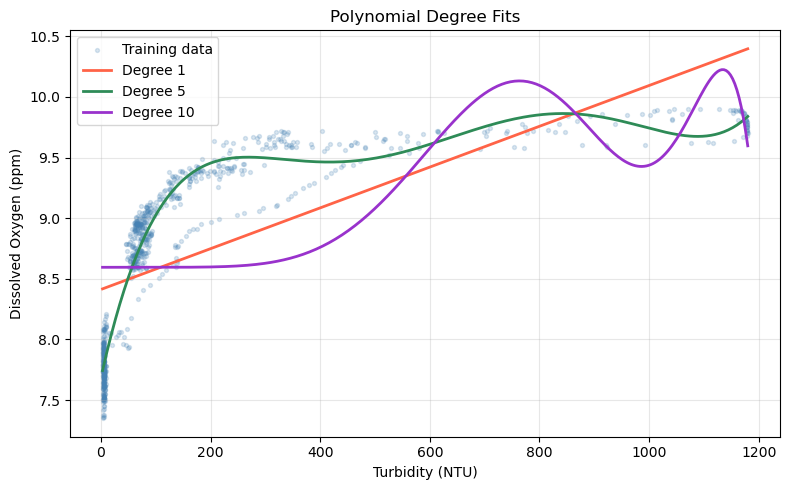

In [191]:
best_degree = degrees[np.argmin(cv_mean_mses)]
best_cv_mse = cv_mean_mses.min()

# Plot 1: CV MSE across degrees
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, cv_mean_mses, marker='o', color='steelblue',
        linewidth=2, markersize=6, label='Mean CV MSE')
ax.axvline(best_degree, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Best degree = {best_degree}  (CV MSE = {best_cv_mse:.4f})')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Mean CV MSE')
ax.set_title('CV MSE vs. Polynomial Degree\n(5-fold CV on training set)')
ax.set_xticks(degrees)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best polynomial degree : {best_degree}')
print(f'Best mean CV MSE       : {best_cv_mse:.4f}')

# Plot 2: Fitted curves for degrees 1, 5, 10 to illustrate under/overfitting

X_range = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train, y_train, alpha=0.2, s=8, color='steelblue', label='Training data')

for deg, color in zip([1, 5, 10], ['tomato', 'seagreen', 'darkorchid']):
    poly    = PolynomialFeatures(degree=deg)
    X_poly  = poly.fit_transform(X_train)
    model   = LinearRegression().fit(X_poly, y_train)
    y_range = model.predict(poly.transform(X_range))
    ax.plot(X_range, y_range, linewidth=2, color=color, label=f'Degree {deg}')

ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('Polynomial Degree Fits')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Evaluate the Best Degree on the Test Set

Fit a final model on **all training data** using the CV-selected degree and evaluate it once on the test set.

1. Fit `PolynomialFeatures(degree=best_degree)` on `X_train`, transform both sets.
2. Fit `LinearRegression` on the transformed training data.
3. Compute test MSE and compare against the linear baseline.
4. Plot the fitted curve over the test scatter.

Linear regression test MSE    : 0.2895
Degree-5 polynomial test MSE : 0.0319


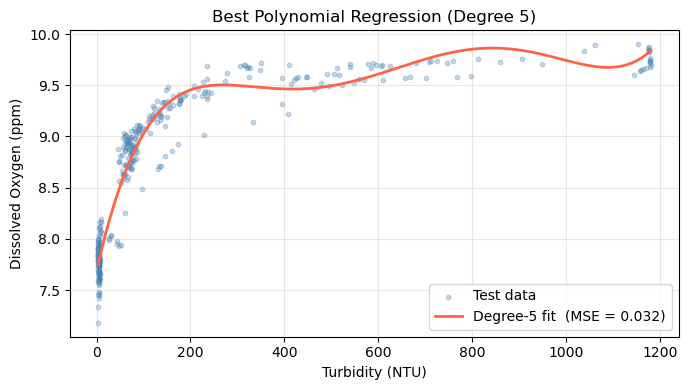

In [192]:
poly_best  = PolynomialFeatures(degree=best_degree)
X_train_p  = poly_best.fit_transform(X_train)
X_test_p   = poly_best.transform(X_test)

model_best = LinearRegression()
model_best.fit(X_train_p, y_train)

y_pred_best = model_best.predict(X_test_p)
mse_best    = mean_squared_error(y_test, y_pred_best)

print(f'Linear regression test MSE    : {mse_linear:.4f}')
print(f'Degree-{best_degree} polynomial test MSE : {mse_best:.4f}')

X_range      = np.linspace(X_test.min(), X_test.max(), 300).reshape(-1, 1)
y_range_pred = model_best.predict(poly_best.transform(X_range))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_test, y_test, alpha=0.3, s=10, color='steelblue', label='Test data')
ax.plot(X_range, y_range_pred, color='tomato', linewidth=2,
        label=f'Degree-{best_degree} fit  (MSE = {mse_best:.3f})')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title(f'Best Polynomial Regression (Degree {best_degree})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()